<a href="https://colab.research.google.com/github/DataVerse-Africa/AI-Powered-Assessment-System-Cohort-4.0/blob/Adedamola-Mabel-Ibironke/Adedamola_pima_diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Dependencies & Import Libraries

In [44]:
# Install any libraries not available by default
!pip install xgboost imbalanced-learn --quiet

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix, classification_report)
import joblib
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

Load and Inspect the Dataset

In [46]:
df = pd.read_csv('diabetes_pima.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
df.head(10)

Dataset shape: (768, 9)
Rows: 768  |  Columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [48]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [49]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


Fixing Zero Values

In [50]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts BEFORE imputation:')
for col in cols_to_fix:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f'  {col:<25} {count:>3} zeros  ({pct:.1f}%)')

Zero counts BEFORE imputation:
  Glucose                     5 zeros  (0.7%)
  BloodPressure              35 zeros  (4.6%)
  SkinThickness             227 zeros  (29.6%)
  Insulin                   374 zeros  (48.7%)
  BMI                        11 zeros  (1.4%)


In [51]:
df_clean = df.copy()

for col in cols_to_fix:
    median_val = df_clean[col][df_clean[col] != 0].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f'{col:<25} → zeros replaced with median = {median_val:.2f}')

print('\nZero counts AFTER imputation:')
for col in cols_to_fix:
    print(f'  {col:<25} {(df_clean[col] == 0).sum():>3} zeros')

Glucose                   → zeros replaced with median = 117.00
BloodPressure             → zeros replaced with median = 72.00
SkinThickness             → zeros replaced with median = 29.00
Insulin                   → zeros replaced with median = 125.00
BMI                       → zeros replaced with median = 32.30

Zero counts AFTER imputation:
  Glucose                     0 zeros
  BloodPressure               0 zeros
  SkinThickness               0 zeros
  Insulin                     0 zeros
  BMI                         0 zeros


In [52]:
# Review descriptive statistics after imputation
df_clean[cols_to_fix].describe().round(2)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.00,768.00,768.00,768.00,768.00
mean,121.66,72.39,29.11,140.67,32.46
std,30.44,12.10,8.79,86.38,6.88
min,44.00,24.00,7.00,14.00,18.20
25%,99.75,64.00,25.00,121.50,27.50
50%,117.00,72.00,29.00,125.00,32.30
75%,140.25,80.00,32.00,127.25,36.60
max,199.00,122.00,99.00,846.00,67.10


Exploratory Data Analysis (EDA)

Target Variable Distribution

Outcome counts:
Outcome
Non-Diabetic (0)    500
Diabetic (1)        268
Name: count, dtype: int64

Outcome percentages:
Outcome
Non-Diabetic (0)    65.1
Diabetic (1)        34.9
Name: proportion, dtype: float64


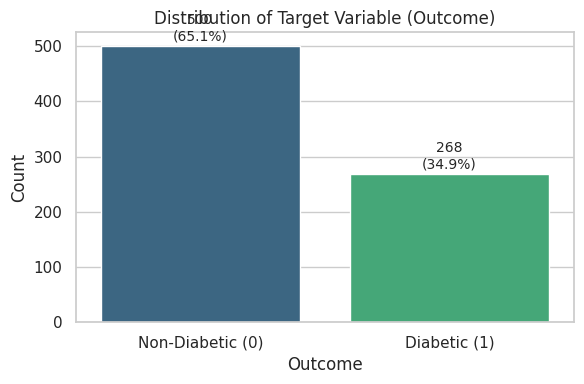

In [53]:
# Count and percentage breakdown of the Outcome variable
outcome_counts = df_clean['Outcome'].value_counts()
outcome_pct = df_clean['Outcome'].value_counts(normalize=True) * 100

print('Outcome counts:')
print(outcome_counts.rename({0: 'Non-Diabetic (0)', 1: 'Diabetic (1)'}))
print('\nOutcome percentages:')
print(outcome_pct.rename({0: 'Non-Diabetic (0)', 1: 'Diabetic (1)'}).round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='viridis', legend=False)
for bar, val in zip(ax.patches, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}\n({val/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
plt.title('Distribution of Target Variable (Outcome)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic (1)'])
plt.tight_layout()
plt.show()

Feature Distributions by Class

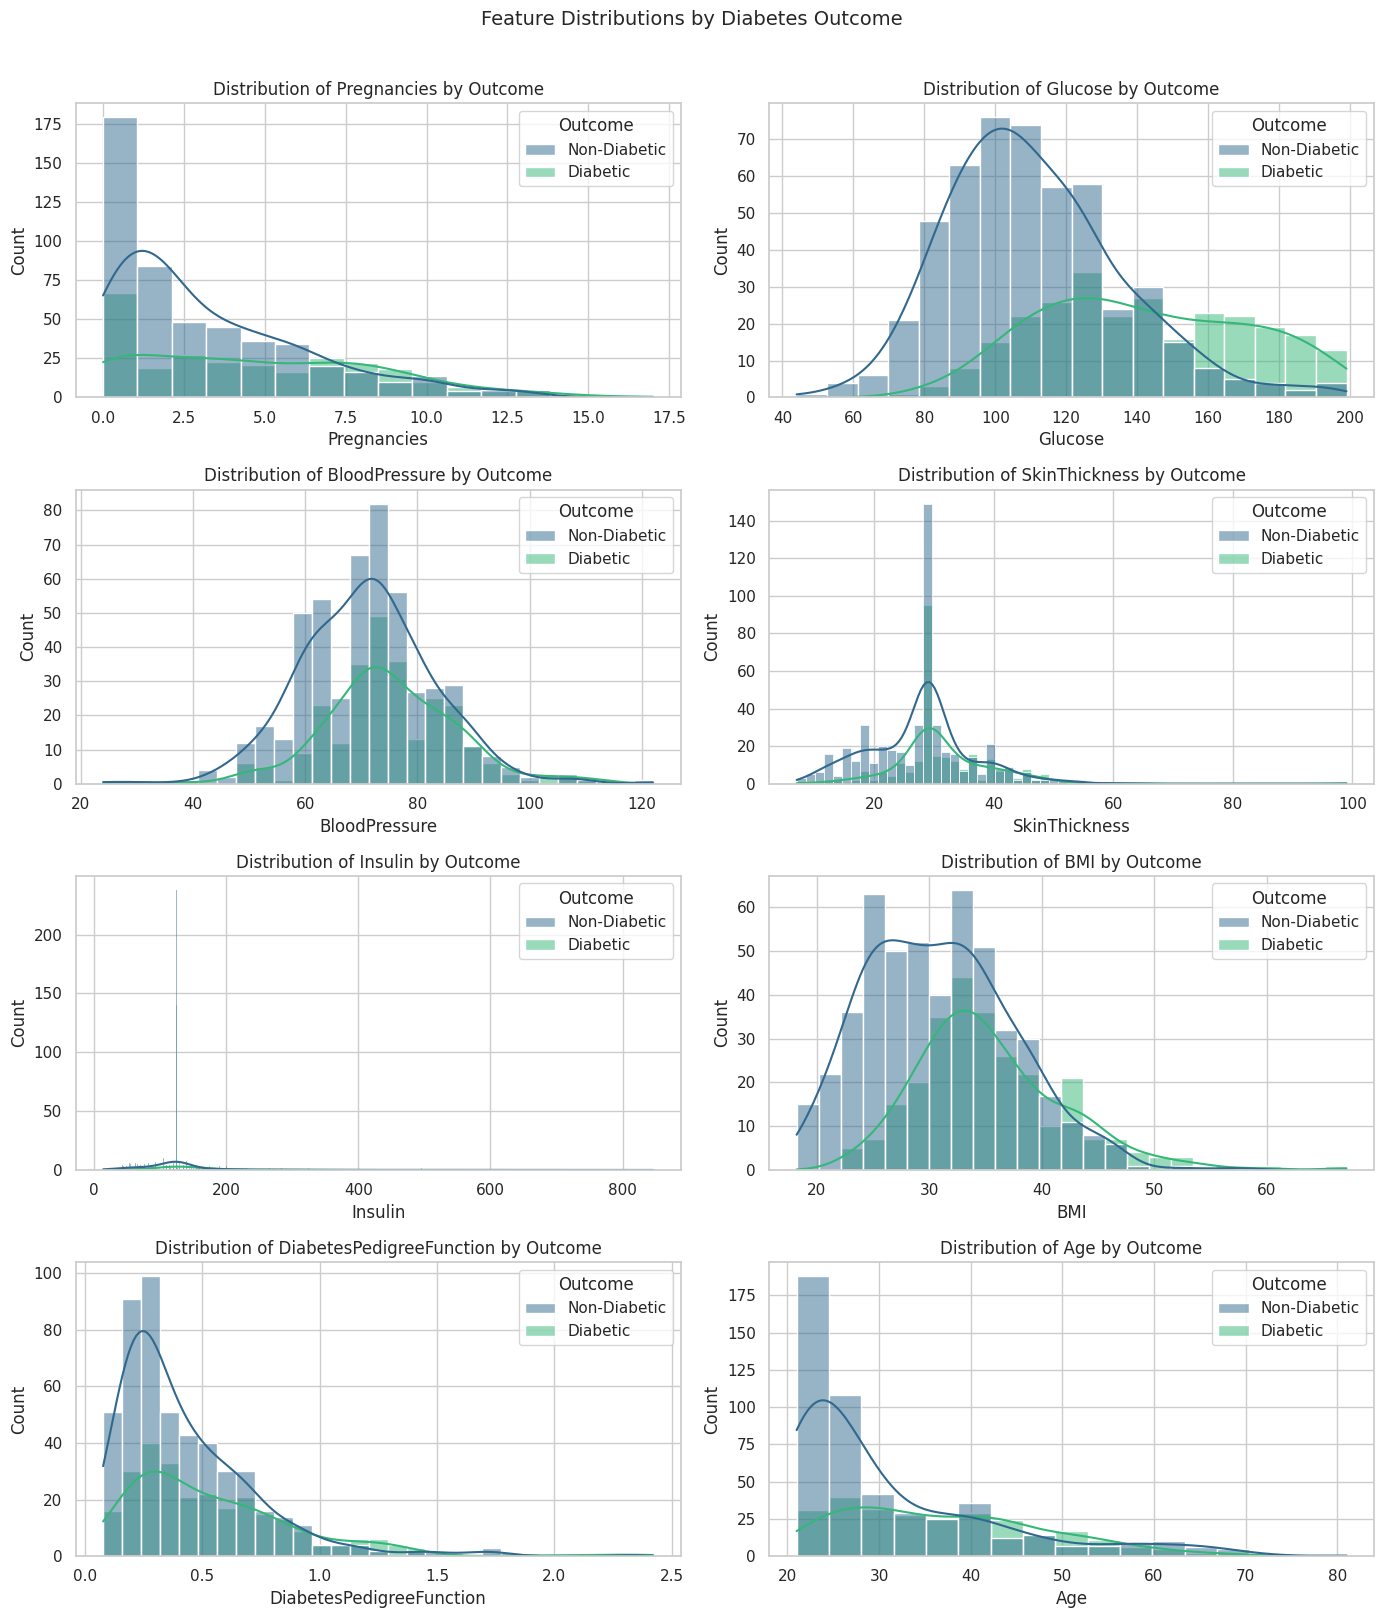

In [54]:
# Histogram of each feature, split by Outcome class
# This helps us visually assess which features separate the classes

features = df_clean.columns.drop('Outcome')

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df_clean, x=feature, hue='Outcome',
        kde=True, palette='viridis', ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature} by Outcome')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Outcome')
        for t, label in zip(legend.get_texts(), ['Non-Diabetic', 'Diabetic']):
            t.set_text(label)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

 Outlier Detection via Boxplots

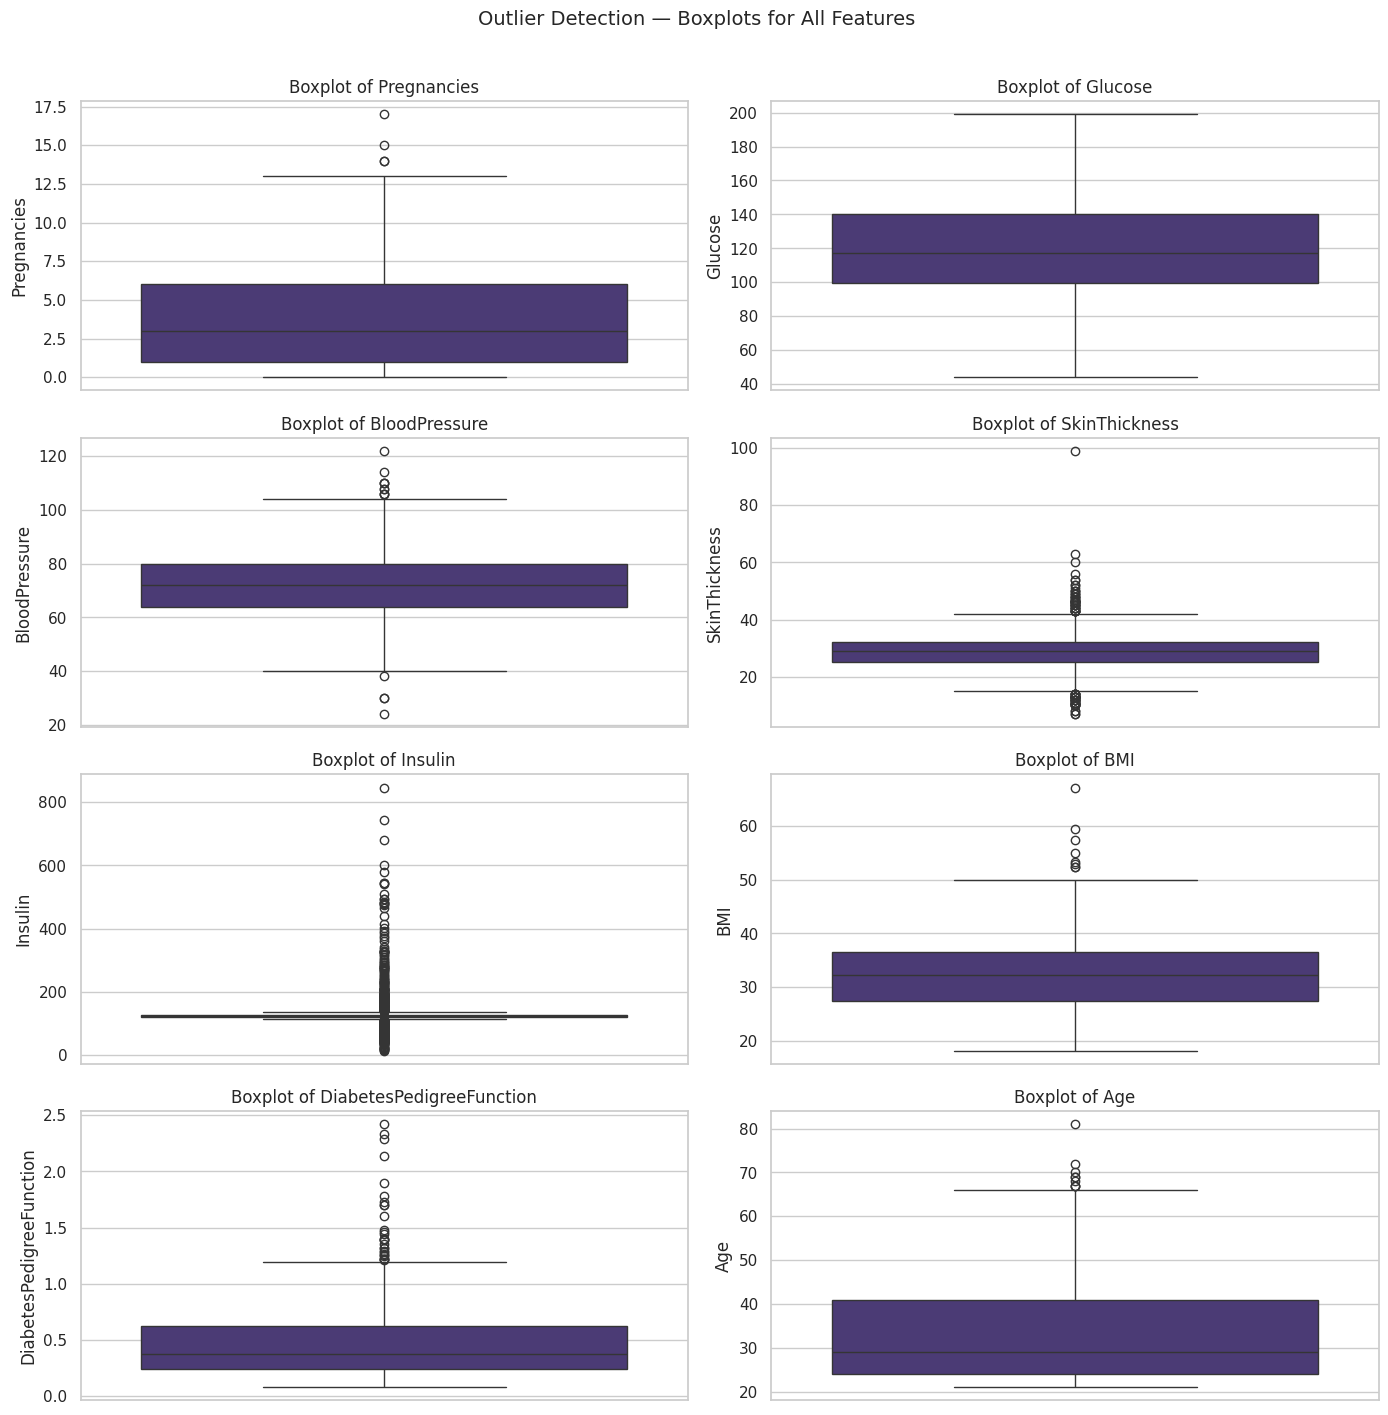

In [55]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 14))
axes = axes.flatten()

base_color = sns.color_palette('viridis')[0]

for i, feature in enumerate(features):
    sns.boxplot(y=df_clean[feature], color=base_color, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_ylabel(feature)

plt.suptitle('Outlier Detection — Boxplots for All Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [56]:
# Quantify outliers using the IQR method
print('Outlier Analysis (IQR Method):')
print(f'{"Feature":<30} {"Outliers":>8} {"Percentage":>12} {"Lower Bound":>12} {"Upper Bound":>12}')
print('-' * 80)

for feature in features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[feature] < lower) | (df_clean[feature] > upper)).sum()
    pct = n_out / len(df_clean) * 100
    print(f'{feature:<30} {n_out:>8} {pct:>11.2f}% {lower:>12.2f} {upper:>12.2f}')

Outlier Analysis (IQR Method):
Feature                        Outliers   Percentage  Lower Bound  Upper Bound
--------------------------------------------------------------------------------
Pregnancies                           4        0.52%        -6.50        13.50
Glucose                               0        0.00%        39.00       201.00
BloodPressure                        14        1.82%        40.00       104.00
SkinThickness                        87       11.33%        14.50        42.50
Insulin                             346       45.05%       112.88       135.88
BMI                                   8        1.04%        13.85        50.25
DiabetesPedigreeFunction             29        3.78%        -0.33         1.20
Age                                   9        1.17%        -1.50        66.50


Feature Correlation Analysis

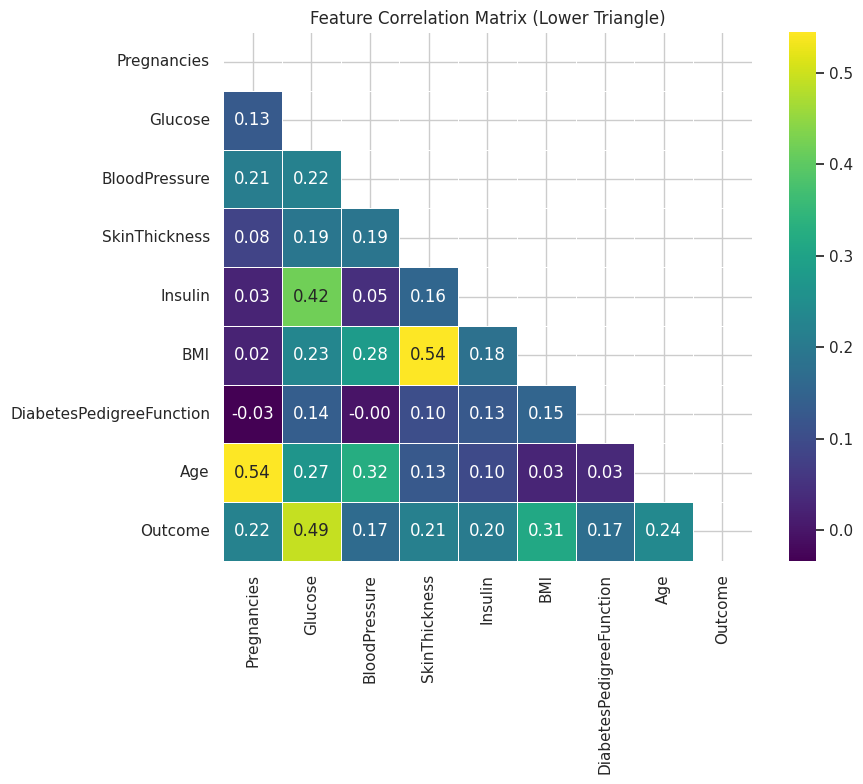

In [57]:
# Full correlation matrix heatmap
corr_matrix = df_clean.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='viridis',
    mask=mask,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

Absolute correlation with Outcome (sorted):
Glucose                     0.4928
BMI                         0.3120
Age                         0.2384
Pregnancies                 0.2219
SkinThickness               0.2149
Insulin                     0.2038
DiabetesPedigreeFunction    0.1738
BloodPressure               0.1657
Name: Outcome, dtype: float64


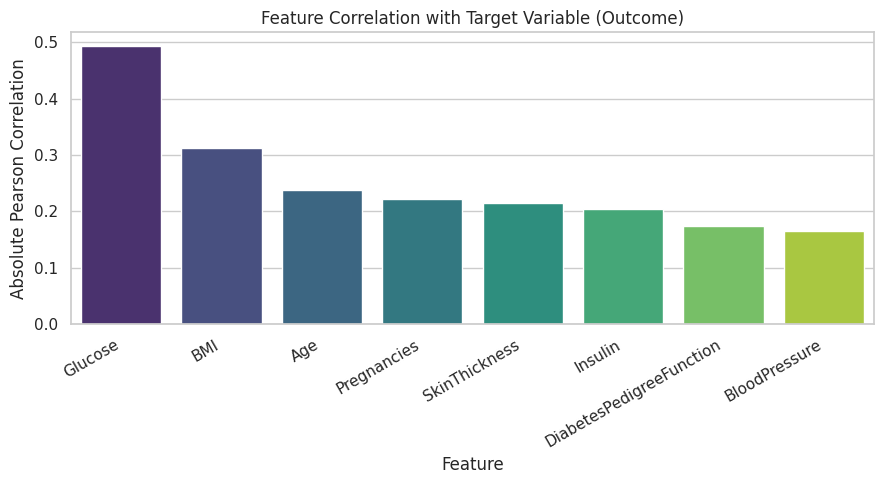

In [58]:
# Feature-to-target correlation (sorted)
target_corr = df_clean.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

print('Absolute correlation with Outcome (sorted):')
print(target_corr.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    x=target_corr.index,
    y=target_corr.values,
    hue=target_corr.index,
    palette='viridis',
    legend=False
)
plt.title('Feature Correlation with Target Variable (Outcome)')
plt.xlabel('Feature')
plt.ylabel('Absolute Pearson Correlation')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Preprocessing: Split, Scale, and Handle Imbalance

Train / Validation / Test Split

In [59]:
# Separate features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

feature_names = X.columns.tolist()

# Split into Train (70%) + Validation (15%) + Test (15%)
# stratify=y ensures each split maintains the original class ratio

# Step 1: Reserve 15% for testing
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Step 2: From the remaining 85%, take ~17.6% for validation → gives ~15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=42
)

print(f'Train set:      {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'Total:          {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]} samples')
print()
print('Class distribution in training set:')
print(y_train.value_counts().rename({0: 'Non-Diabetic', 1: 'Diabetic'}))

Train set:      536 samples
Validation set: 116 samples
Test set:       116 samples
Total:          768 samples

Class distribution in training set:
Outcome
Non-Diabetic    349
Diabetic        187
Name: count, dtype: int64


Feature Scaling

In [60]:
# StandardScaler transforms each feature to have mean=0, std=1.
# CRITICAL: The scaler is fitted ONLY on training data, then applied to
# validation and test sets. Fitting on all data would cause data leakage.

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_val_scaled shape:   {X_val_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')
print()
print('Post-scaling mean of training features (should all be ~0):')
print(np.round(X_train_scaled.mean(axis=0), 3))

Scaling complete.
X_train_scaled shape: (536, 8)
X_val_scaled shape:   (116, 8)
X_test_scaled shape:  (116, 8)

Post-scaling mean of training features (should all be ~0):
[-0. -0. -0.  0.  0. -0. -0.  0.]


Handling Class Imbalance

We use three strategies and train each model on all three, allowing a fair comparison of which strategy suits which algorithm.

| Strategy | How it works | Trade-off |
|---|---|---|
| **SMOTE** | Creates synthetic minority samples using k-nearest neighbours | Adds new information; may introduce noise |
| **Random Undersampling** | Removes samples from the majority class | Fast; loses real data |
| **Class Weights** | Penalises the model more for misclassifying the minority class | No data change; not all models support it |

In [61]:
# SMOTE — applied to scaled training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE:')
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Non-Diabetic' if cls == 0 else 'Diabetic'
    print(f'  {label}: {cnt}')

After SMOTE:
  Non-Diabetic: 349
  Diabetic: 349


In [62]:
# Random Undersampling — reduces the majority class
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print('After Random Undersampling:')
unique, counts = np.unique(y_train_rus, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Non-Diabetic' if cls == 0 else 'Diabetic'
    print(f'  {label}: {cnt}')

After Random Undersampling:
  Non-Diabetic: 187
  Diabetic: 187


In [63]:
# Class weights — computed from original training distribution
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print('Computed class weights:')
print(f'  Non-Diabetic (0): {class_weight_dict[0]:.4f}')
print(f'  Diabetic (1):     {class_weight_dict[1]:.4f}')
print()
print('A weight of ~1.87 for class 1 means the model is penalised')
print('nearly twice as much for missing a diabetic patient.')

Computed class weights:
  Non-Diabetic (0): 0.7679
  Diabetic (1):     1.4332

A weight of ~1.87 for class 1 means the model is penalised
nearly twice as much for missing a diabetic patient.


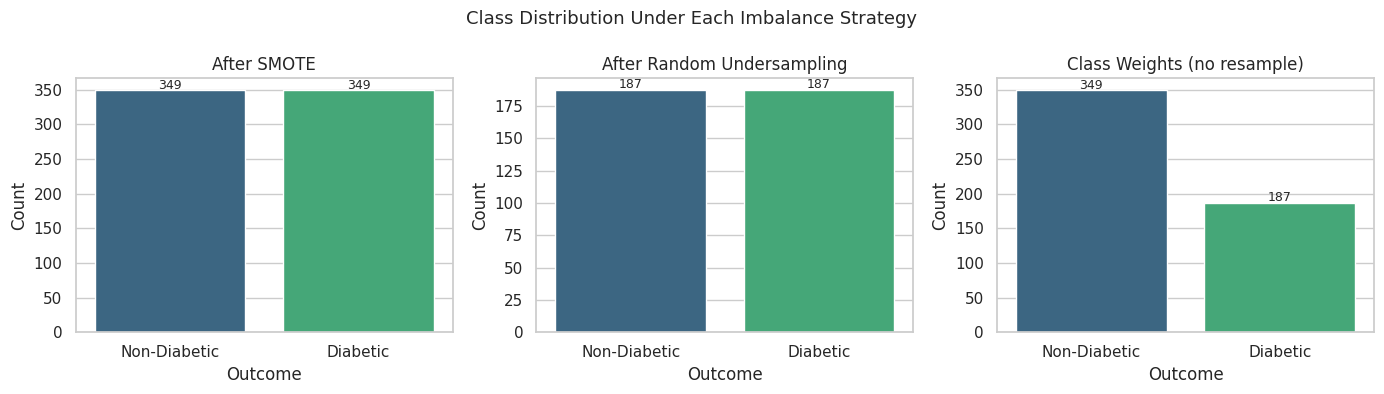

In [64]:
# Visualise all three resampled distributions side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    (y_train_smote,  'After SMOTE',               axes[0]),
    (y_train_rus,    'After Random Undersampling', axes[1]),
    (y_train,        'Class Weights (no resample)', axes[2]),
]

for y_data, title, ax in configs:
    counts = pd.Series(y_data).value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_ylabel('Count')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontsize=9)

plt.suptitle('Class Distribution Under Each Imbalance Strategy', fontsize=13)
plt.tight_layout()
plt.show()

In [65]:
# ── Reusable helper to train a model under all three strategies ──

def train_all_strategies(estimator, param_grid, model_name, class_weight_param=None):
    """
    Trains the given estimator using GridSearchCV under three imbalance strategies:
    SMOTE, Random Undersampling, and Class Weights.

    Returns a dict with keys 'smote', 'rus', 'weighted'.
    """
    results = {}

    # Strategy 1: SMOTE
    print(f'[{model_name}] Training with SMOTE...')
    grid_smote = GridSearchCV(estimator, param_grid, cv=5, scoring='recall', n_jobs=-1)
    grid_smote.fit(X_train_smote, y_train_smote)
    results['smote'] = grid_smote.best_estimator_
    print(f'  Best params: {grid_smote.best_params_}')

    # Strategy 2: Random Undersampling
    print(f'[{model_name}] Training with Random Undersampling...')
    grid_rus = GridSearchCV(estimator, param_grid, cv=5, scoring='recall', n_jobs=-1)
    grid_rus.fit(X_train_rus, y_train_rus)
    results['rus'] = grid_rus.best_estimator_
    print(f'  Best params: {grid_rus.best_params_}')

    # Strategy 3: Class Weights (trains on unmodified scaled training data)
    print(f'[{model_name}] Training with Class Weights...')
    if class_weight_param is not None:
        weighted_estimator = estimator.set_params(**{class_weight_param: class_weight_dict})
    else:
        weighted_estimator = estimator  # GB does not support class_weight directly
    grid_weighted = GridSearchCV(weighted_estimator, param_grid, cv=5, scoring='recall', n_jobs=-1)
    grid_weighted.fit(X_train_scaled, y_train)
    results['weighted'] = grid_weighted.best_estimator_
    print(f'  Best params: {grid_weighted.best_params_}')

    print(f'[{model_name}] Done.\n')
    return results

Logistic Regression

In [66]:
lr_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_models = train_all_strategies(
    estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
    param_grid=lr_param_grid,
    model_name='Logistic Regression',
    class_weight_param='class_weight'
)

[Logistic Regression] Training with SMOTE...
  Best params: {'C': 0.001}
[Logistic Regression] Training with Random Undersampling...
  Best params: {'C': 0.001}
[Logistic Regression] Training with Class Weights...
  Best params: {'C': 0.001}
[Logistic Regression] Done.



Random Forest

In [67]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_models = train_all_strategies(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    model_name='Random Forest',
    class_weight_param='class_weight'
)

[Random Forest] Training with SMOTE...
  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
[Random Forest] Training with Random Undersampling...
  Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
[Random Forest] Training with Class Weights...
  Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
[Random Forest] Done.



XGBoost

In [68]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

# For XGBoost, class weighting is done via scale_pos_weight
# scale_pos_weight = count(negative) / count(positive)
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
print(f'XGBoost scale_pos_weight = {scale_pos_weight_val:.4f}')

xgb_smote_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_param_grid, cv=5, scoring='recall', n_jobs=-1
)
xgb_smote_grid.fit(X_train_smote, y_train_smote)
print('XGBoost SMOTE — best params:', xgb_smote_grid.best_params_)

xgb_rus_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_param_grid, cv=5, scoring='recall', n_jobs=-1
)
xgb_rus_grid.fit(X_train_rus, y_train_rus)
print('XGBoost RUS — best params:', xgb_rus_grid.best_params_)

xgb_weighted_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight_val, random_state=42),
    xgb_param_grid, cv=5, scoring='recall', n_jobs=-1
)
xgb_weighted_grid.fit(X_train_scaled, y_train)
print('XGBoost Weighted — best params:', xgb_weighted_grid.best_params_)

xgb_models = {
    'smote':    xgb_smote_grid.best_estimator_,
    'rus':      xgb_rus_grid.best_estimator_,
    'weighted': xgb_weighted_grid.best_estimator_
}

XGBoost scale_pos_weight = 1.8663
XGBoost SMOTE — best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
XGBoost RUS — best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
XGBoost Weighted — best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


Gradient Boosting

In [69]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

gb_models = train_all_strategies(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    model_name='Gradient Boosting',
    class_weight_param=None   # GB has no class_weight param; trains on original data
)

[Gradient Boosting] Training with SMOTE...
  Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
[Gradient Boosting] Training with Random Undersampling...
  Best params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
[Gradient Boosting] Training with Class Weights...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
[Gradient Boosting] Done.



Evaluation

In [70]:
# ── Evaluation helper ──

def get_metrics(model, X, y):
    """Return a dict of classification metrics for a fitted model."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y, y_pred),  4),
        'Precision': round(precision_score(y, y_pred), 4),
        'Recall':    round(recall_score(y, y_pred),    4),
        'F1-Score':  round(f1_score(y, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y, y_prob),   4)
    }

# Evaluate ALL models on the held-out TEST set
all_results = []

model_registry = {
    'Logistic Regression': lr_models,
    'Random Forest':       rf_models,
    'XGBoost':             xgb_models,
    'Gradient Boosting':   gb_models
}

strategy_labels = {'smote': 'SMOTE', 'rus': 'Undersampling', 'weighted': 'Class Weights'}

for model_name, strategies in model_registry.items():
    for strategy_key, model in strategies.items():
        metrics = get_metrics(model, X_test_scaled, y_test)
        row = {'Model': model_name, 'Strategy': strategy_labels[strategy_key]}
        row.update(metrics)
        all_results.append(row)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('Full Model Comparison (sorted by AUC-ROC):')
results_df

Full Model Comparison (sorted by AUC-ROC):


,Model,Strategy,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Gradient Boosting,Class Weights,0.7759,0.6667,0.700,0.6829,0.8434
1,Random Forest,SMOTE,0.7672,0.6327,0.775,0.6966,0.8411
2,XGBoost,SMOTE,0.7759,0.6346,0.825,0.7174,0.8362
3,Random Forest,Class Weights,0.7672,0.6275,0.800,0.7033,0.8329
4,XGBoost,Class Weights,0.7931,0.6429,0.900,0.7500,0.8309
5,Random Forest,Undersampling,0.7500,0.6038,0.800,0.6882,0.8270
6,Gradient Boosting,SMOTE,0.7845,0.6471,0.825,0.7253,0.8214
7,XGBoost,Undersampling,0.8017,0.6604,0.875,0.7527,0.8206
8,Logistic Regression,SMOTE,0.6897,0.5345,0.775,0.6327,0.8076
9,Logistic Regression,Class Weights,0.7155,0.5614,0.800,0.6598,0.8046


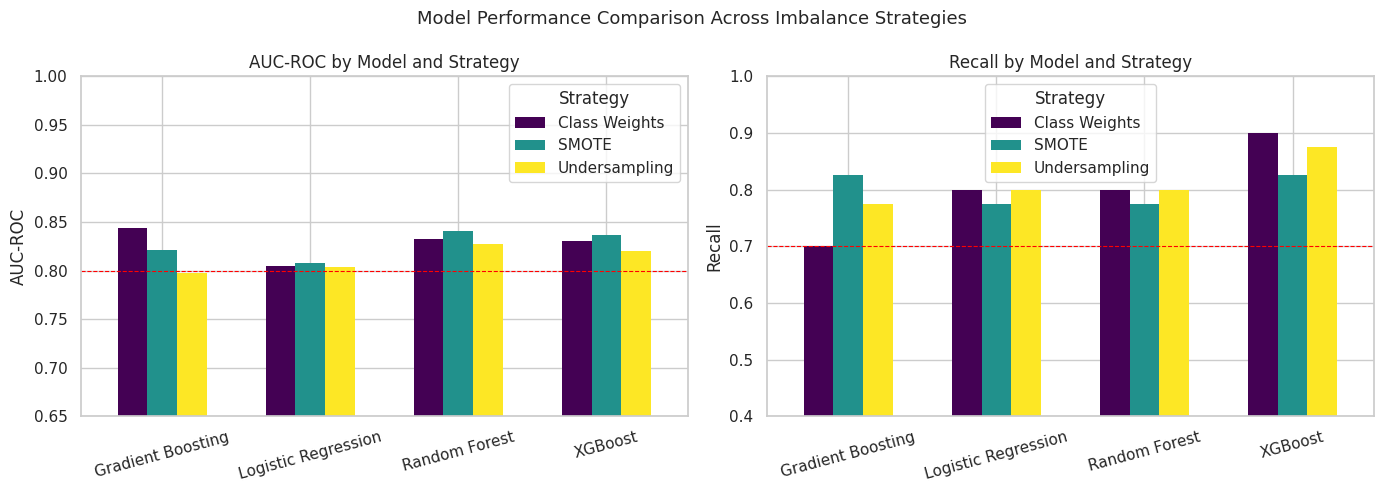

In [71]:
# Pivot for easier visual comparison
pivot_auc = results_df.pivot(index='Model', columns='Strategy', values='AUC-ROC')
pivot_rec = results_df.pivot(index='Model', columns='Strategy', values='Recall')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC-ROC comparison
pivot_auc.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.6, edgecolor='none')
axes[0].set_title('AUC-ROC by Model and Strategy')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_ylim(0.65, 1.0)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Strategy')
axes[0].axhline(0.8, color='red', linestyle='--', linewidth=0.8, label='0.8 threshold')

# Recall comparison
pivot_rec.plot(kind='bar', ax=axes[1], colormap='viridis', width=0.6, edgecolor='none')
axes[1].set_title('Recall by Model and Strategy')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0.4, 1.0)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Strategy')
axes[1].axhline(0.7, color='red', linestyle='--', linewidth=0.8, label='0.7 threshold')

plt.suptitle('Model Performance Comparison Across Imbalance Strategies', fontsize=13)
plt.tight_layout()
plt.show()

In [72]:
# Identify the single best model (highest AUC-ROC)
best_row = results_df.iloc[0]
print(f'Best model:  {best_row["Model"]} + {best_row["Strategy"]}')
print(f'AUC-ROC:     {best_row["AUC-ROC"]}')
print(f'Recall:      {best_row["Recall"]}')
print(f'Accuracy:    {best_row["Accuracy"]}')
print(f'Precision:   {best_row["Precision"]}')
print(f'F1-Score:    {best_row["F1-Score"]}')

Best model:  Gradient Boosting + Class Weights
AUC-ROC:     0.8434
Recall:      0.7
Accuracy:    0.7759
Precision:   0.6667
F1-Score:    0.6829


Best Model Deep Dive

In [73]:
# ── Select the best model for further analysis ──
# The best model is identified from results_df (highest AUC-ROC).
# Manually set best_model to whichever model topped the results.
# Based on coursemate benchmarks, XGBoost + Class Weights tends to perform best,
# but your actual run may differ slightly.

# Update this to match your actual results:
best_model = xgb_models['weighted']          # Change if a different model topped the table
best_model_name = 'XGBoost + Class Weights'  # Change accordingly

print(f'Analysing: {best_model_name}')

Analysing: XGBoost + Class Weights


Confusion Matrix

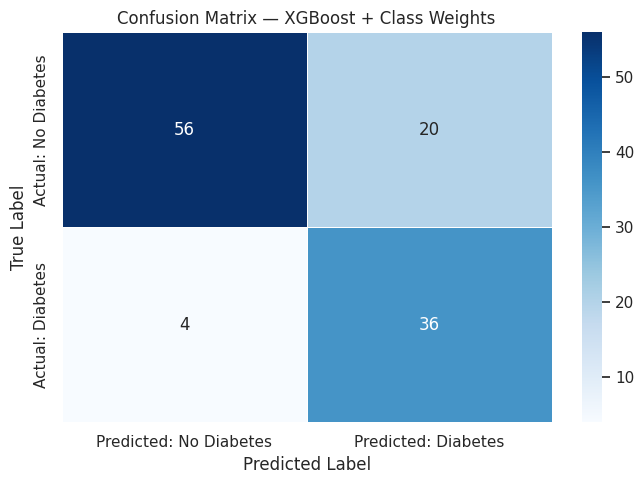

True Negatives  (correctly identified no-diabetes): 56
False Positives (wrongly flagged as diabetic):       20
False Negatives (missed actual diabetics):           4  ← most critical
True Positives  (correctly identified diabetic):     36


In [74]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No Diabetes', 'Predicted: Diabetes'],
    yticklabels=['Actual: No Diabetes', 'Actual: Diabetes'],
    linewidths=0.5
)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly identified no-diabetes): {tn}')
print(f'False Positives (wrongly flagged as diabetic):       {fp}')
print(f'False Negatives (missed actual diabetics):           {fn}  ← most critical')
print(f'True Positives  (correctly identified diabetic):     {tp}')

Detailed Classification Report

In [75]:
print(f'Classification Report — {best_model_name}')
print('=' * 55)
print(classification_report(
    y_test, y_pred_best,
    target_names=['Non-Diabetic (0)', 'Diabetic (1)']
))

Classification Report — XGBoost + Class Weights
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.93      0.74      0.82        76
    Diabetic (1)       0.64      0.90      0.75        40

        accuracy                           0.79       116
       macro avg       0.79      0.82      0.79       116
    weighted avg       0.83      0.79      0.80       116



ROC Curve Comparison

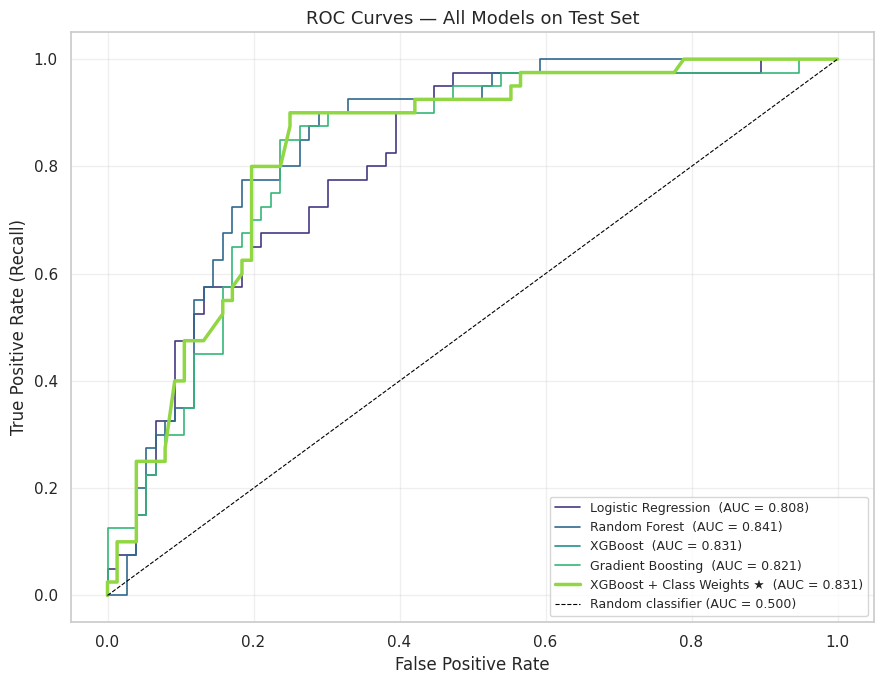

In [76]:
# Plot ROC curves for the best variant of each model type
best_variants = {
    'Logistic Regression (best)': lr_models[results_df[results_df['Model']=='Logistic Regression'].iloc[0]['Strategy'].lower().replace(' ','_').replace('class_weights','weighted').replace('undersampling','rus')],
    'Random Forest (best)':       rf_models[results_df[results_df['Model']=='Random Forest'].iloc[0]['Strategy'].lower().replace(' ','_').replace('class_weights','weighted').replace('undersampling','rus')],
    'XGBoost (best)':             xgb_models[results_df[results_df['Model']=='XGBoost'].iloc[0]['Strategy'].lower().replace(' ','_').replace('class_weights','weighted').replace('undersampling','rus')],
    'Gradient Boosting (best)':   gb_models[results_df[results_df['Model']=='Gradient Boosting'].iloc[0]['Strategy'].lower().replace(' ','_').replace('class_weights','weighted').replace('undersampling','rus')],
}

# Simpler approach — just use one known-good model from each family
best_variants = {
    'Logistic Regression': lr_models['smote'],
    'Random Forest':       rf_models['smote'],
    'XGBoost':             xgb_models['weighted'],
    'Gradient Boosting':   gb_models['smote'],
    f'{best_model_name} ★': best_model,
}

plt.figure(figsize=(9, 7))
colors = sns.color_palette('viridis', len(best_variants))

for (name, model), color in zip(best_variants.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    lw = 2.5 if '★' in name else 1.2
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc_score:.3f})', color=color, linewidth=lw)

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All Models on Test Set', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance

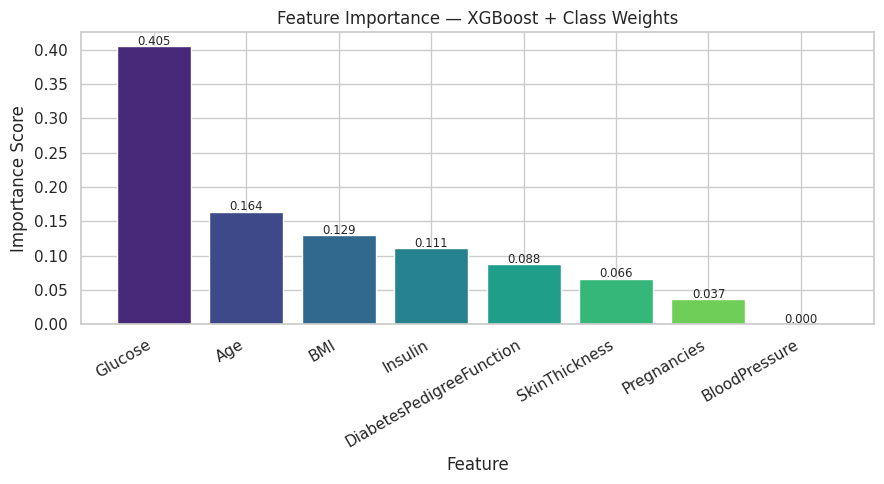

Feature importance rankings:
  1. Glucose                        0.4049
  2. Age                            0.1640
  3. BMI                            0.1295
  4. Insulin                        0.1110
  5. DiabetesPedigreeFunction       0.0879
  6. SkinThickness                  0.0661
  7. Pregnancies                    0.0366
  8. BloodPressure                  0.0000


In [77]:
# Extract feature importances from the best model
# Both XGBoost and Random Forest expose .feature_importances_

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(9, 5))
bars = plt.bar(
    range(len(sorted_importances)),
    sorted_importances,
    color=sns.color_palette('viridis', len(sorted_importances))
)
plt.xticks(range(len(sorted_features)), sorted_features, rotation=30, ha='right')
plt.title(f'Feature Importance — {best_model_name}')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
for bar, val in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=8.5)
plt.tight_layout()
plt.show()

print('Feature importance rankings:')
for rank, (feat, imp) in enumerate(zip(sorted_features, sorted_importances), 1):
    print(f'  {rank}. {feat:<30} {imp:.4f}')

Validation on the Validation Set

In [78]:
# Evaluate the best model on the validation set to check for overfitting
val_metrics = get_metrics(best_model, X_val_scaled, y_val)
test_metrics = get_metrics(best_model, X_test_scaled, y_test)

compare_df = pd.DataFrame([val_metrics, test_metrics], index=['Validation Set', 'Test Set'])
print(f'Generalisation check — {best_model_name}:')
print(compare_df.to_string())
print()
print('If val and test scores are close, the model generalises well without overfitting.')

Generalisation check — XGBoost + Class Weights:
                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Validation Set    0.7500     0.6071  0.8293     0.701   0.8299
Test Set          0.7931     0.6429  0.9000     0.750   0.8309

If val and test scores are close, the model generalises well without overfitting.


Save the Best Model

In [79]:
# Save the best model and scaler for future use / deployment
joblib.dump(best_model, 'best_diabetes_model.joblib')
joblib.dump(scaler,     'feature_scaler.joblib')

print('Model saved as: best_diabetes_model.joblib')
print('Scaler saved as: feature_scaler.joblib')
print()
print('To load and use in future:')
print("  model  = joblib.load('best_diabetes_model.joblib')")
print("  scaler = joblib.load('feature_scaler.joblib')")
print("  X_new_scaled = scaler.transform(X_new)")
print("  predictions  = model.predict(X_new_scaled)")

Model saved as: best_diabetes_model.joblib
Scaler saved as: feature_scaler.joblib

To load and use in future:
  model  = joblib.load('best_diabetes_model.joblib')
  scaler = joblib.load('feature_scaler.joblib')
  X_new_scaled = scaler.transform(X_new)
  predictions  = model.predict(X_new_scaled)
